In [4]:
# ============================================================
# Grinold & Kahn Chapter 1 Implementation Lab
# Step 1: Imports + Define Universe + Market Portfolio
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: install first if needed
# !pip install yfinance

import yfinance as yf

# -----------------------------
# 1. Define asset universe
# -----------------------------

risky_assets = [
    "VXUS",  # International equities
    "VTI",   # Total US market
    "QQQM",  # Nasdaq-100
    "SPYG",  # S&P 500 Growth
    "NFLX",  # Netflix
    "AMZN",  # Amazon
    "AAPL",  # Apple
    "TLT",   # Long-term Treasuries
    "GLD",   # Gold
    "VOO",   # S&P 500
    "BND"    # Total bond market
]

risk_free_asset = "CASH"

assets = risky_assets + [risk_free_asset]

# -----------------------------
# 2. Define risk-free rate
# -----------------------------

risk_free_rate_annual = 0.04
risk_free_rate_monthly = (1 + risk_free_rate_annual) ** (1 / 12) - 1

# -----------------------------
# 3. Define toy market portfolio
# Market-cap-ish weights
# -----------------------------

market_weights = pd.Series(
    {
        "VXUS": 0.15,
        "VTI":  0.35,
        "QQQM": 0.10,
        "SPYG": 0.05,
        "NFLX": 0.01,
        "AMZN": 0.03,
        "AAPL": 0.03,
        "TLT":  0.02,
        "GLD":  0.01,
        "VOO":  0.20,
        "BND":  0.04,
        "CASH": 0.01,
    }
)

# Check weights sum to 1
assert np.isclose(market_weights.sum(), 1.0), "Market weights must sum to 1."

# -----------------------------
# 4. Display market portfolio
# -----------------------------

market_portfolio = pd.DataFrame({
    "Asset": market_weights.index,
    "Weight": market_weights.values
})

market_portfolio["Weight (%)"] = market_portfolio["Weight"] * 100

market_portfolio

,Asset,Weight,Weight (%)
0,VXUS,0.15,15.0
1,VTI,0.35,35.0
2,QQQM,0.10,10.0
3,SPYG,0.05,5.0
4,NFLX,0.01,1.0
5,AMZN,0.03,3.0
6,AAPL,0.03,3.0
7,TLT,0.02,2.0
8,GLD,0.01,1.0
9,VOO,0.20,20.0


## Asset Returns

For asset $i$, return at time $t$ is:

$$
R_{i,t} = \frac{P_{i,t} - P_{i,t-1}}{P_{i,t-1}}
$$

where:

- $P_{i,t}$ = price at time $t$
- $P_{i,t-1}$ = price at previous time

## Expected Excess Returns

Define the expected excess return vector:

$$
f =
\begin{bmatrix}
f_1 \\
f_2 \\
\vdots \\
f_n
\end{bmatrix}
$$

where each component is:

$$
f_i = E[R_i] - R_f
$$

Under CAPM:

$$
f_i = \beta_i f_{mkt}
$$

In [6]:
# ============================================================
# Step 2: Download price data and compute monthly returns
# ============================================================

start_date = "2020-01-01"
end_date = None

prices = yf.download(
    risky_assets,
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

# Monthly prices (last trading day of each month)
monthly_prices = prices.resample("ME").last()

# Monthly returns
returns = monthly_prices.pct_change().dropna()


[*********************100%***********************]  11 of 11 completed


Ticker,AAPL,AMZN,BND,GLD,NFLX,QQQM,SPYG,TLT,VOO,VTI,VXUS
Date,,,,,,,,,,,
2020-11-30,0.095493,0.043440,0.012135,-0.054086,0.031446,0.109598,0.096933,0.016639,0.109466,0.118031,0.126153
2020-12-31,0.114574,0.028058,0.001525,0.070139,0.101956,0.049660,0.039824,-0.012276,0.037444,0.046763,0.058443
2021-01-31,-0.005501,-0.015576,-0.008618,-0.032238,-0.015424,0.003568,-0.004522,-0.036328,-0.010213,-0.003340,0.002494
2021-02-28,-0.079712,-0.035328,-0.015477,-0.062569,0.012134,0.002705,-0.000363,-0.057330,0.027662,0.031393,0.023047
2021-03-31,0.007340,0.000372,-0.012714,-0.011433,-0.031901,0.012798,0.027221,-0.052452,0.045752,0.036479,0.018697


## Covariance

Covariance between assets $i$ and $j$:

$$
Cov(R_i, R_j)
=
E[(R_i - E[R_i])(R_j - E[R_j])]
$$

Interpretation:

- Positive covariance → assets move together
- Negative covariance → assets move opposite
- Zero covariance → no linear relationship

## Covariance Matrix

The covariance matrix $V$ is:

$$
V =
\begin{bmatrix}
\sigma_1^2 & cov_{12} & \cdots & cov_{1n} \\
cov_{21} & \sigma_2^2 & \cdots & cov_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
cov_{n1} & cov_{n2} & \cdots & \sigma_n^2
\end{bmatrix}
$$

where:

$$
V_{ij} = Cov(R_i, R_j)
$$

In [10]:
# Covariance matrix of monthly returns
V = returns.cov()

# compute market returns
risky_market_weights = market_weights[risky_assets]

# Normalize risky weights to sum to 1 (excluding cash)
risky_market_weights = risky_market_weights / risky_market_weights.sum()

# Ensure exact ordering
weights_aligned = risky_market_weights.loc[V.columns]
w = weights_aligned.values

# Method 1
market_variance_matrix = w.T @ V.values @ w

# Method 2
market_returns = returns[V.columns] @ weights_aligned
market_variance_series = market_returns.var(ddof=1)

print("Matrix variance:", market_variance_matrix)
print("Series variance:", market_variance_series)
print("Difference:", market_variance_matrix - market_variance_series)

Matrix variance: 0.00193435650174746
Series variance: 0.0019343565017474593
Difference: 6.505213034913027e-19
0.0028537422475375007 0.0019343565017474593


## Sharpe Ratio

Sharpe ratio measures excess return per unit risk:

$$
SR
=
\frac{E[R_p]-R_f}
{\sigma_p}
$$

In [11]:
#sharpe ratio
market_mean_return = market_returns.mean()

market_excess_return = market_mean_return - risk_free_rate_monthly

market_sharpe = market_excess_return / market_variance_matrix

market_sharpe

np.float64(4.957435729050879)

## Portfolio C: Fully Invested Minimum-Variance Portfolio

We want the lowest-risk portfolio subject to being fully invested.

The portfolio variance is:

$$
\sigma_p^2 = h^T V h
$$

where:

- $h$ = portfolio weight vector
- $V$ = covariance matrix of asset returns

The full-investment constraint is:

$$
e^T h = 1
$$

where:

$$
e =
\begin{bmatrix}
1 \\
1 \\
\vdots \\
1
\end{bmatrix}
$$

So the optimization problem is:

$$
\min_h h^T V h
$$

subject to:

$$
e^T h = 1
$$

The closed-form solution is:

$$
h_C =
\frac{V^{-1}e}
{e^T V^{-1}e}
$$

This portfolio is the minimum-risk portfolio among all portfolios whose weights sum to 1.

In [12]:
# ============================================================
# Portfolio C: Fully Invested Minimum-Variance Portfolio
# ============================================================

# Use the covariance matrix V from risky asset returns
# V should have rows/columns matching risky_assets

V_mat = V.values
asset_names = V.columns.tolist()

# Vector of ones
e = np.ones(len(asset_names))

# Inverse covariance matrix
V_inv = np.linalg.inv(V_mat)

# Minimum-variance fully invested portfolio
h_C = V_inv @ e / (e.T @ V_inv @ e)

# Put weights into a readable Series
h_C = pd.Series(h_C, index=asset_names, name="Portfolio C Weight")

# Portfolio C statistics
C_expected_return = returns[asset_names].mean() @ h_C
C_variance = h_C.T @ V_mat @ h_C
C_volatility = np.sqrt(C_variance)

# Display
C_summary = pd.DataFrame({
    "Weight": h_C,
    "Weight (%)": h_C * 100
})

print("Portfolio C expected monthly return:", C_expected_return)
print("Portfolio C variance:", C_variance)
print("Portfolio C volatility:", C_volatility)
print("Sum of weights:", h_C.sum())

C_summary

Portfolio C expected monthly return: 0.00206925959170871
Portfolio C variance: 6.113427768484884e-05
Portfolio C volatility: 0.007818841198339357
Sum of weights: 0.9999999999999993


,Weight,Weight (%)
AAPL,-0.019037,-1.903677
AMZN,-0.034820,-3.482002
BND,1.640037,164.003738
GLD,0.048043,4.804286
NFLX,-0.030353,-3.035328
QQQM,0.076943,7.694295
SPYG,0.017036,1.703637
TLT,-0.522457,-52.245713
VOO,-0.360118,-36.011823
VTI,0.444412,44.441231


## Portfolio Q and Efficient Frontier

We construct Portfolio Q using CAPM expected returns.

### CAPM Expected Excess Returns

Beta of asset $i$:

$$
\beta_i=
\frac{Cov(R_i,R_M)}
{Var(R_M)}
$$

CAPM expected excess return:

$$
f_i = \beta_i f_{mkt}
$$

where:

$$
f_{mkt}=E[R_M]-R_f
$$

---

### Portfolio Q

Portfolio Q minimizes variance subject to unit return exposure:

$$
\min_h h^T V h
$$

subject to:

$$
f^T h=1
$$

Closed-form solution:

$$
h_Q=
\frac{V^{-1}f}
{f^T V^{-1}f}
$$

---

### Efficient Frontier

All fully invested efficient portfolios can be written as:

$$
h(\theta)=h_C+\theta(h_Q-h_C)
$$

where:

- $h_C$ = minimum variance portfolio
- $h_Q$ = unit return characteristic portfolio
- $\theta$ controls risk / return exposure

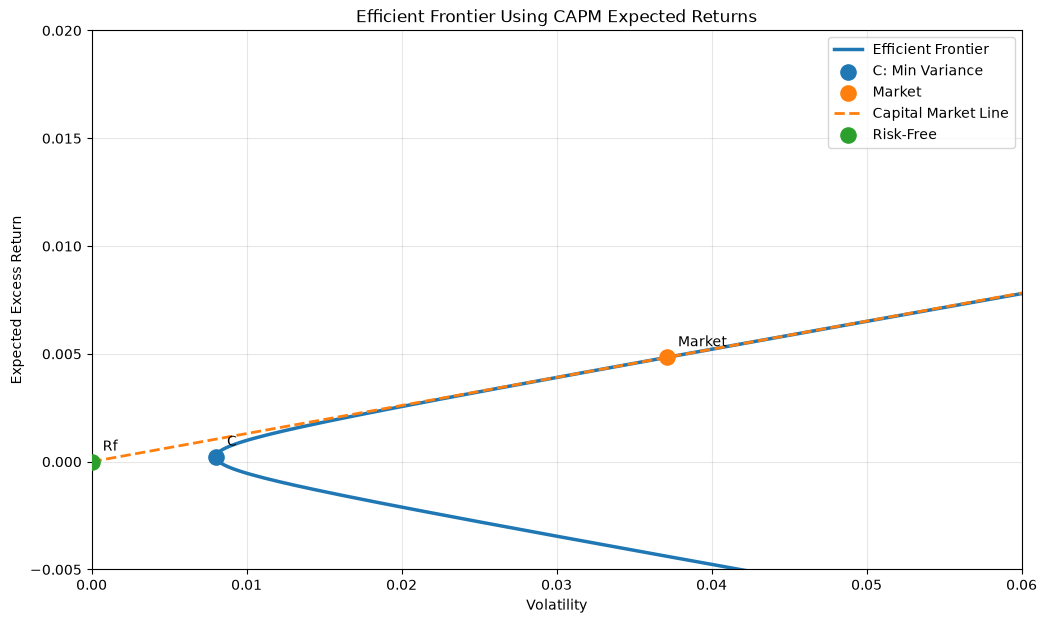

Ticker   BND   DBC   GLD   TLT    VB   VNQ   VTI  VXUS   XLE   XLU
Ticker                                                            
BND     1.00 -0.11  0.40  0.88  0.43  0.61  0.47  0.55  0.07  0.42
DBC    -0.11  1.00  0.05 -0.30  0.41  0.31  0.37  0.43  0.69  0.19
GLD     0.40  0.05  1.00  0.34  0.08  0.21  0.13  0.34 -0.00  0.36
TLT     0.88 -0.30  0.34  1.00  0.15  0.41  0.19  0.24 -0.19  0.28
VB      0.43  0.41  0.08  0.15  1.00  0.83  0.93  0.83  0.64  0.48
VNQ     0.61  0.31  0.21  0.41  0.83  1.00  0.81  0.78  0.47  0.65
VTI     0.47  0.37  0.13  0.19  0.93  0.81  1.00  0.85  0.56  0.50
VXUS    0.55  0.43  0.34  0.24  0.83  0.78  0.85  1.00  0.56  0.52
XLE     0.07  0.69 -0.00 -0.19  0.64  0.47  0.56  0.56  1.00  0.29
XLU     0.42  0.19  0.36  0.28  0.48  0.65  0.50  0.52  0.29  1.00


In [23]:
# ============================================================
# Portfolio Q + Efficient Frontier
# Direct constrained solution, using CAPM expected excess returns
# ============================================================

MODE = "plot"      # "debug" or "plot"
SHOW_CML = True

# -----------------------------
# Step 0: Align data
# -----------------------------
asset_names = V.columns.tolist()

returns_aligned = returns[asset_names]
V_mat = V.loc[asset_names, asset_names].values
V_inv = np.linalg.inv(V_mat)

e = np.ones(len(asset_names))

market_w = risky_market_weights.loc[asset_names]
market_w = market_w / market_w.sum()

market_returns = returns_aligned @ market_w
market_var = market_returns.var(ddof=1)

# -----------------------------
# Step 1: Compute Betas
# -----------------------------
betas = pd.Series(
    {
        asset: returns_aligned[asset].cov(market_returns) / market_var
        for asset in asset_names
    },
    name="Beta"
)

# -----------------------------
# Step 2: CAPM Expected Excess Returns
# -----------------------------
market_excess_return = market_returns.mean() - risk_free_rate_monthly

f_capm = betas * market_excess_return
f = f_capm.loc[asset_names].values

# Historical expected excess returns instead of CAPM returns
# f_hist = returns_aligned.mean() - risk_free_rate_monthly
# f = f_hist.loc[asset_names].values


# -----------------------------
# Step 3: Construct Portfolio Q
# -----------------------------
h_Q_values = (V_inv @ f) / (f.T @ V_inv @ f)
h_Q = pd.Series(h_Q_values, index=asset_names, name="Portfolio Q")

# -----------------------------
# Step 4: Construct Portfolio C
# Minimum-variance fully invested portfolio
# -----------------------------
h_C_values = (V_inv @ e) / (e.T @ V_inv @ e)
h_C = pd.Series(h_C_values, index=asset_names, name="Portfolio C")

C_return = f @ h_C.values
C_var = h_C.values.T @ V_mat @ h_C.values
C_vol = np.sqrt(C_var)

# -----------------------------
# Step 5: Market portfolio stats
# -----------------------------
M_return = f @ market_w.values
M_var = market_w.values.T @ V_mat @ market_w.values
M_vol = np.sqrt(M_var)
M_beta = market_w.values @ betas.loc[asset_names].values

# -----------------------------
# Step 6: Efficient Frontier
# Solve:
# min h'Vh
# s.t. e'h = 1
#      f'h = target_return
# -----------------------------
A = np.array([
    [e.T @ V_inv @ e, e.T @ V_inv @ f],
    [f.T @ V_inv @ e, f.T @ V_inv @ f]
])

target_min = C_return - 0.02
target_max = max(M_return * 5, C_return + 0.05)

frontier_targets = np.linspace(target_min, target_max, 800)

frontier_returns = []
frontier_vols = []
frontier_weights = []

for target_return in frontier_targets:
    b = np.array([1, target_return])
    lambdas = np.linalg.solve(A, b)

    h = V_inv @ (lambdas[0] * e + lambdas[1] * f)

    port_return = f @ h
    port_var = h.T @ V_mat @ h
    port_vol = np.sqrt(max(port_var, 0))

    frontier_returns.append(port_return)
    frontier_vols.append(port_vol)
    frontier_weights.append(h)

frontier_returns = np.array(frontier_returns)
frontier_vols = np.array(frontier_vols)

# -----------------------------
# Step 7: Debug Output
# -----------------------------
if MODE == "debug":
    print("=== Betas ===")
    display(betas)

    print("=== CAPM Expected Excess Returns ===")
    display(f_capm)

    print("=== Portfolio Q Weights ===")
    display(h_Q)

    print("=== Portfolio C Weights ===")
    display(h_C)

    print("=== Checks ===")
    print("f^T h_Q:", f @ h_Q.values)
    print("e^T h_C:", e @ h_C.values)
    print("Market beta:", M_beta)

    print("\n=== Stats ===")
    print("C return:", C_return)
    print("C volatility:", C_vol)
    print("Market return:", M_return)
    print("Market volatility:", M_vol)
    print("Market variance:", M_var)

# -----------------------------
# Step 8: Plot
# -----------------------------
if MODE == "plot":
    plt.figure(figsize=(12, 7))

    plt.plot(
        frontier_vols,
        frontier_returns,
        linewidth=2.5,
        label="Efficient Frontier"
    )

    plt.scatter(C_vol, C_return, s=120, label="C: Min Variance", zorder=5)
    plt.annotate("C", (C_vol, C_return), xytext=(8, 8), textcoords="offset points")

    plt.scatter(M_vol, M_return, s=120, label="Market", zorder=5)
    plt.annotate("Market", (M_vol, M_return), xytext=(8, 8), textcoords="offset points")

    if SHOW_CML:
        cml_vols = np.linspace(0, frontier_vols.max(), 400)
        cml_returns = (M_return / M_vol) * cml_vols

        plt.plot(
            cml_vols,
            cml_returns,
            linestyle="--",
            linewidth=2,
            label="Capital Market Line"
        )

        plt.scatter(0, 0, s=120, label="Risk-Free", zorder=5)
        plt.annotate("Rf", (0, 0), xytext=(8, 8), textcoords="offset points")

    plt.xlabel("Volatility")
    plt.ylabel("Expected Excess Return")
    plt.title("Efficient Frontier Using CAPM Expected Returns")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.xlim(0, 0.06)
    plt.ylim(-0.005, 0.02)
    plt.show()
print(returns.corr().round(2))

## Efficient Frontier Exercise: Less-Correlated Market Universe

Our first universe had many highly overlapping assets, such as VTI, VOO, QQQM, and SPYG. Because those assets move very similarly, the covariance matrix had many high correlations, and the efficient frontier looked almost linear.

In this exercise, we build a broader, more diversified toy market portfolio using assets with more distinct risk exposures:

- U.S. equities
- international equities
- small-cap equities
- real estate
- bonds
- long-term Treasuries
- gold
- commodities
- energy
- utilities
- cash

The goal is to make the efficient frontier curvature easier to see.

We will:

1. Define a broader asset universe.
2. Define a market portfolio over that universe.
3. Download monthly returns.
4. Compute the covariance matrix.
5. Compute CAPM-implied expected excess returns.
6. Construct portfolio C, the fully invested minimum-variance portfolio.
7. Plot the efficient frontier and Capital Market Line.

The core optimization problem for each target return is:

$$
\min_h h^T V h
$$

subject to:

$$
e^T h = 1
$$

and

$$
f^T h = f_p
$$

where:

- $h$ = portfolio weights
- $V$ = covariance matrix
- $e$ = vector of ones
- $f$ = CAPM expected excess return vector
- $f_p$ = target expected excess return

The risk-free asset is cash, assumed to earn 4% annually.

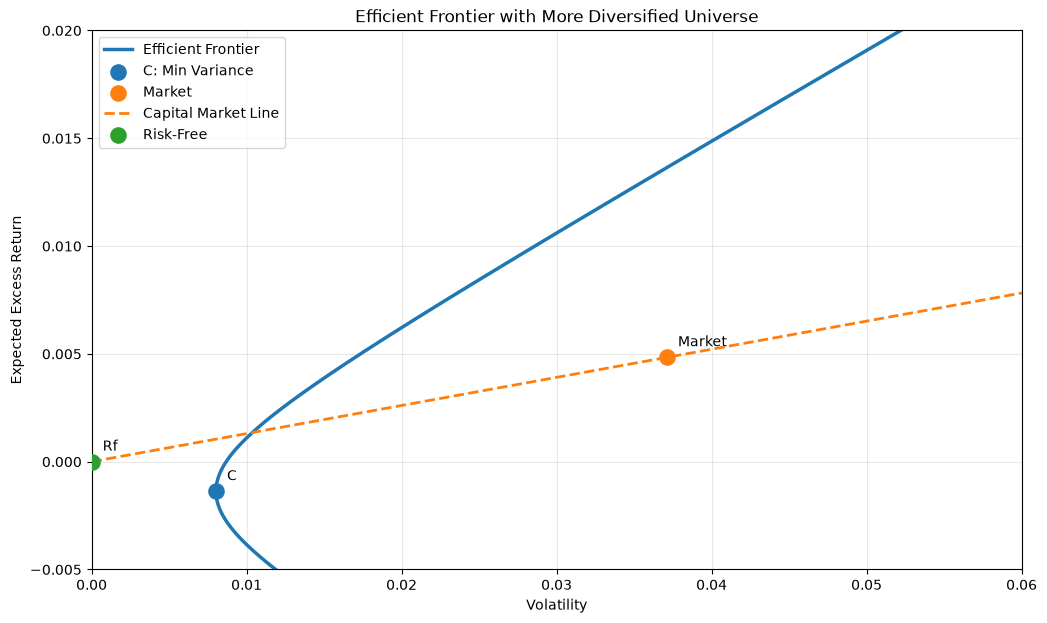

In [21]:
# ============================================================
# Efficient Frontier Exercise: Less-Correlated Market Universe
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# -----------------------------
# Toggle
# -----------------------------
MODE = "plot"      # "debug" or "plot"
SHOW_CML = True

# -----------------------------
# 1. Define broader asset universe
# -----------------------------
risky_assets = [
    "VTI",   # US total stock market
    "VXUS",  # International equities
    "VB",    # US small cap
    "VNQ",   # REITs / real estate
    "BND",   # US aggregate bonds
    "TLT",   # Long-term Treasuries
    "GLD",   # Gold
    "DBC",   # Broad commodities
    "XLE",   # Energy sector
    "XLU"    # Utilities sector
]

risk_free_asset = "CASH"

risk_free_rate_annual = 0.04
risk_free_rate_monthly = (1 + risk_free_rate_annual) ** (1 / 12) - 1

# -----------------------------
# 2. Define toy market portfolio
# -----------------------------
market_weights = pd.Series(
    {
        "VTI":  0.35,
        "VXUS": 0.15,
        "VB":   0.08,
        "VNQ":  0.07,
        "BND":  0.15,
        "TLT":  0.05,
        "GLD":  0.05,
        "DBC":  0.03,
        "XLE":  0.04,
        "XLU":  0.02,
        "CASH": 0.01,
    }
)

assert np.isclose(market_weights.sum(), 1.0), "Market weights must sum to 1."

# -----------------------------
# 3. Download prices and compute monthly returns
# -----------------------------
start_date = "2018-01-01"
end_date = None

prices = yf.download(
    risky_assets,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)["Close"]

monthly_prices = prices.resample("ME").last()
returns = monthly_prices.pct_change().dropna()

# -----------------------------
# 4. Align data
# -----------------------------
asset_names = returns.columns.tolist()
returns_aligned = returns[asset_names]

risky_market_weights = market_weights.loc[asset_names]
risky_market_weights = risky_market_weights / risky_market_weights.sum()

# -----------------------------
# 5. Covariance matrix
# -----------------------------
V = returns_aligned.cov()
V_mat = V.values
V_inv = np.linalg.inv(V_mat)

e = np.ones(len(asset_names))

# -----------------------------
# 6. Market portfolio returns and risk
# -----------------------------
market_returns = returns_aligned @ risky_market_weights

market_var = market_returns.var(ddof=1)
market_vol = np.sqrt(market_var)

market_excess_return = market_returns.mean() - risk_free_rate_monthly

# -----------------------------
# 7. Compute betas
# -----------------------------
betas = pd.Series(
    {
        asset: returns_aligned[asset].cov(market_returns) / market_var
        for asset in asset_names
    },
    name="Beta"
)

# # -----------------------------
# # 8. CAPM expected excess returns
# # -----------------------------
# f_capm = betas * market_excess_return
# f = f_capm.loc[asset_names].values

# Historical expected excess returns instead of CAPM returns
f_hist = returns_aligned.mean() - risk_free_rate_monthly
f = f_hist.loc[asset_names].values

# -----------------------------
# 9. Portfolio C: fully invested minimum-variance portfolio
# -----------------------------
h_C_values = (V_inv @ e) / (e.T @ V_inv @ e)
h_C = pd.Series(h_C_values, index=asset_names, name="Portfolio C")

C_return = f @ h_C.values
C_var = h_C.values.T @ V_mat @ h_C.values
C_vol = np.sqrt(C_var)

# -----------------------------
# 10. Portfolio Q: unit return characteristic portfolio
# -----------------------------
h_Q_values = (V_inv @ f) / (f.T @ V_inv @ f)
h_Q = pd.Series(h_Q_values, index=asset_names, name="Portfolio Q")

# -----------------------------
# 11. Market portfolio stats
# -----------------------------
M_return = f @ risky_market_weights.values
M_var = risky_market_weights.values.T @ V_mat @ risky_market_weights.values
M_vol = np.sqrt(M_var)
M_beta = risky_market_weights.values @ betas.loc[asset_names].values

# -----------------------------
# 12. Efficient frontier
# -----------------------------
A = np.array([
    [e.T @ V_inv @ e, e.T @ V_inv @ f],
    [f.T @ V_inv @ e, f.T @ V_inv @ f]
])

target_min = C_return - 0.02
target_max = max(M_return * 5, C_return + 0.05)

frontier_targets = np.linspace(target_min, target_max, 800)

frontier_returns = []
frontier_vols = []
frontier_weights = []

for target_return in frontier_targets:
    b = np.array([1, target_return])
    lambdas = np.linalg.solve(A, b)

    h = V_inv @ (lambdas[0] * e + lambdas[1] * f)

    port_return = f @ h
    port_var = h.T @ V_mat @ h
    port_vol = np.sqrt(max(port_var, 0))

    frontier_returns.append(port_return)
    frontier_vols.append(port_vol)
    frontier_weights.append(h)

frontier_returns = np.array(frontier_returns)
frontier_vols = np.array(frontier_vols)

# -----------------------------
# 13. Debug output
# -----------------------------
if MODE == "debug":
    print("=== Market weights ===")
    display(market_weights)

    print("=== Correlation matrix ===")
    display(returns_aligned.corr().round(2))

    print("=== Betas ===")
    display(betas)

    print("=== CAPM expected excess returns ===")
    display(f_capm)

    print("=== Portfolio C weights ===")
    display(h_C)

    print("=== Portfolio Q weights ===")
    display(h_Q)

    print("=== Checks ===")
    print("Sum of market risky weights:", risky_market_weights.sum())
    print("Market beta:", M_beta)
    print("e^T h_C:", e @ h_C.values)
    print("f^T h_Q:", f @ h_Q.values)

    print("\n=== Stats ===")
    print("C return:", C_return)
    print("C volatility:", C_vol)
    print("Market return:", M_return)
    print("Market volatility:", M_vol)
    print("Market variance:", M_var)
    print("Market excess return:", market_excess_return)

# -----------------------------
# 14. Plot
# -----------------------------
if MODE == "plot":
    plt.figure(figsize=(12, 7))

    plt.plot(
        frontier_vols,
        frontier_returns,
        linewidth=2.5,
        label="Efficient Frontier"
    )

    plt.scatter(C_vol, C_return, s=120, label="C: Min Variance", zorder=5)
    plt.annotate("C", (C_vol, C_return), xytext=(8, 8), textcoords="offset points")

    plt.scatter(M_vol, M_return, s=120, label="Market", zorder=5)
    plt.annotate("Market", (M_vol, M_return), xytext=(8, 8), textcoords="offset points")

    if SHOW_CML:
        cml_vols = np.linspace(0, frontier_vols.max(), 400)
        cml_returns = (M_return / M_vol) * cml_vols

        plt.plot(
            cml_vols,
            cml_returns,
            linestyle="--",
            linewidth=2,
            label="Capital Market Line"
        )

        plt.scatter(0, 0, s=120, label="Risk-Free", zorder=5)
        plt.annotate("Rf", (0, 0), xytext=(8, 8), textcoords="offset points")

    plt.xlabel("Volatility")
    plt.ylabel("Expected Excess Return")
    plt.title("Efficient Frontier with More Diversified Universe")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.xlim(0, 0.06)
    plt.ylim(-0.005, 0.02)
    plt.show()